In [1]:
# Load the TensorBoard notebook extension
%load_ext tensorboard


import tensorflow as tf
import numpy as np 
import matplotlib.pyplot as plt

import keras

print(tf.__version__)

2025-04-05 19:36:53.947081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.19.0


# phase one:
## load data

In [2]:
## load data and assert the correct number for data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train= keras.utils.to_categorical(y_train, num_classes=10)
y_test= keras.utils.to_categorical(y_test, num_classes=10)

assert x_train.shape == (50000, 32, 32, 3)
assert y_train.shape == (50000,10)

assert x_test.shape == (10000, 32, 32, 3)
assert y_test.shape == (10000, 10 )

#create val and test set
x_val = x_test[:5000]
x_test = x_test[5000:]
y_val = y_test[:5000]
y_test = y_test[5000:]


assert x_val.shape == (5000, 32, 32, 3)
assert y_val.shape == (5000, 10 )

assert x_test.shape == (5000, 32, 32, 3)
assert y_test.shape == (5000, 10 )
map2name={ 
0:	'airplane',
1:	'automobile',
2:	'bird',
3:	'cat',
4:	'deer',
5:	'dog',
6:	'frog',
7:	'horse',
8:	'ship',
9:	'truck',    
}

Text(0.5, 1.0, 'label is frog')

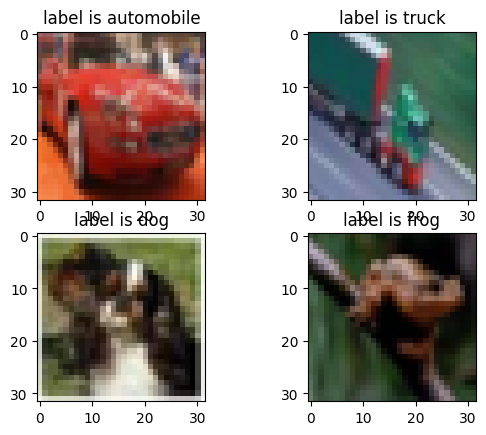

In [3]:
## Visualize some sample

f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(x_train[5])
axarr[0,0].set_title(f'label is {map2name.get(y_train[5].argmax())}')
axarr[0,1].imshow(x_train[50])
axarr[0,1].set_title(f'label is {map2name.get(y_train[50].argmax())}')

axarr[1,0].imshow(x_train[500])
axarr[1,0].set_title(f'label is {map2name.get(y_train[500].argmax())}')

axarr[1,1].imshow(x_train[5000])
axarr[1,1].set_title(f'label is {map2name.get(y_train[5000].argmax())}')


# phase 2:
## create model
 1.  we will use panda method.
 2. would use rescale layer
 3. would use 2 convs and2 maxpool 
 4. would use 3 dense with Relu
 
 

In [4]:
#prepare layers

#utilits
data_in = keras.layers.InputLayer(shape=(32,32,3))
rescale = keras.layers.Rescaling(scale=1./255)
data_out = keras.layers.Dense(units=10,activation='softmax')
drop75 = keras.layers.Dropout(rate=0.75)
drop50 = keras.layers.Dropout(rate=0.50)
drop25 = keras.layers.Dropout(rate=0.25)
# conv family
conv1 = keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')
conv2 = keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')
maxpool = keras.layers.MaxPool2D(pool_size=(2,2))
flat = keras.layers.Flatten()

# dense family
dense1 = keras.layers.Dense(units=256, activation='relu')
dense2 = keras.layers.Dense(units=512, activation='relu')
dense3 = keras.layers.Dense(units=128, activation='relu')

#add layers to model
model = keras.models.Sequential()
model.add(data_in)
model.add(rescale)
model.add(conv1)
model.add(maxpool)
model.add(drop50)
model.add(conv2)
model.add(maxpool)
model.add(flat)
#model.add(drop75) #lose too much info deepseek suggest 20-50
model.add(drop25)
model.add(dense1)
model.add(drop50)
model.add(dense2)
model.add(drop50)
model.add(dense3)
model.add(drop25)
model.add(data_out)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021,002 (3.89 MB)

 Trainable params: 1,021,002 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#model seems good
#procced to compile
model.compile(optimizer='Adam',
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=['categorical_crossentropy','categorical_accuracy'],             
             )

In [6]:
#custom call  back for +90 percent acc
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        '''
        Halts the training when the accuravy rise  above 90%

        Args:
            epoch (integer) - index of epoch (required but unused in the function definition below)
            logs (dict) - metric results from the training epoch
        '''

        # Check the loss
        if logs['categorical_accuracy'] > 90:

            # Stop if threshold is met
            print("\nLoss is lower than 0.4 so cancelling training!")
            self.model.stop_training = True
tensorboard_callback = keras.callbacks.TensorBoard(log_dir="./logs")

In [7]:
keras.utils.plot_model(model, show_shapes=True)



You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [8]:
epochs = 1
history = model.fit(x=x_train, y=y_train, batch_size=128, validation_data=(x_val,y_val),
          callbacks=[myCallback(),tensorboard_callback],
          epochs=epochs,
          )

2025-04-05 19:37:00.536418: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 153600000 exceeds 10% of free system memory.


391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 138ms/step - categorical_accuracy: 0.2131 - categorical_crossentropy: 2.0657 - loss: 2.0657 - val_categorical_accuracy: 0.4438 - val_categorical_crossentropy: 1.5298 - val_loss: 1.5298


In [10]:
%tensorboard --bind_all --logdir logs  --port 7776

